In [1]:
import warnings
warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API", category=UserWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from helpers import prep_the_data

In [3]:
df_nta = pd.read_parquet("../data/processed/features/complaints_311_nta_category.parquet")
df_nta = prep_the_data(df_nta)

# Ensure datetime once (upstream helpers may already do this, but keep it explicit)
df_nta.head()

,complaint_date,time_of_day,nta_id,nta_name,borough,category,complaint_count,dow,month,is_weekend,month_year,dow_complaint
0,2022-01-01,day,BK0101,Greenpoint,Brooklyn,Commercial Noise,1,Saturday,January,1,January__2022,COMMERCIAL_NOISE__Saturday
1,2022-01-01,day,BK0101,Greenpoint,Brooklyn,Garbage Collection,1,Saturday,January,1,January__2022,GARBAGE_COLLECTION__Saturday
2,2022-01-01,day,BK0101,Greenpoint,Brooklyn,Parking Issues,1,Saturday,January,1,January__2022,PARKING_ISSUES__Saturday
3,2022-01-01,day,BK0101,Greenpoint,Brooklyn,Tree Requests,1,Saturday,January,1,January__2022,TREE_REQUESTS__Saturday
4,2022-01-01,day,BK0102,Williamsburg,Brooklyn,Commercial Noise,1,Saturday,January,1,January__2022,COMMERCIAL_NOISE__Saturday


### Filter analysis window

In [4]:
# Adjust these if you want a different window
START_DATE = "2022-01-01"
END_DATE   = "2024-12-31"  # exclusive upper bound

df_nta_2021__2024 = df_nta.loc[
    (df_nta["complaint_date"] >= START_DATE) &
    (df_nta["complaint_date"] <  END_DATE)
].copy()

df_nta_2021__2024.shape, df_nta_2021__2024["complaint_date"].min(), df_nta_2021__2024["complaint_date"].max()

((2294283, 12),
 Timestamp('2022-01-01 00:00:00'),
 Timestamp('2024-12-30 00:00:00'))

#### 1) NYC overall: how many 311 complaints per day?

In [5]:
def daily_citywide_totals(df: pd.DataFrame) -> pd.Series:
    """Citywide daily totals (sum across all geographies), indexed by date."""
    return (
        df.groupby(df["complaint_date"].dt.date)["complaint_count"]
          .sum()
          .sort_index()
    )

In [6]:
daily_totals = daily_citywide_totals(df_nta_2021__2024)

summary_table = pd.DataFrame({
    "Metric": [
        "Average complaints per day",
        "Median complaints per day",
        "Quietest day (min)",
        "Noisiest day (max)",
        "Number of days analyzed",
    ],
    "Value": [
        round(daily_totals.mean(), 1),
        int(daily_totals.median()),
        int(daily_totals.min()),
        int(daily_totals.max()),
        int(daily_totals.shape[0]),
    ],
})

summary_table

,Metric,Value
0,Average complaints per day,4571.9
1,Median complaints per day,4504.0
2,Quietest day (min),16.0
3,Noisiest day (max),14034.0
4,Number of days analyzed,1057.0


#### 2) Heatmap: reason × time of day

In [7]:
# Average daily complaints by descriptor_group × time_of_day
daily_descriptor = (
    df_nta_2021__2024
    .groupby([df_nta_2021__2024["complaint_date"].dt.date, "category", "time_of_day"])["complaint_count"]
    .sum()
    .reset_index(name="daily_complaints")
)

typical_day = (
    daily_descriptor
    .groupby(["category", "time_of_day"])["daily_complaints"]
    .mean()
    .reset_index(name="avg_complaints_per_day")
)

heatmap_df = (
    typical_day
    .pivot(index="category", columns="time_of_day", values="avg_complaints_per_day")
    .fillna(0)
)


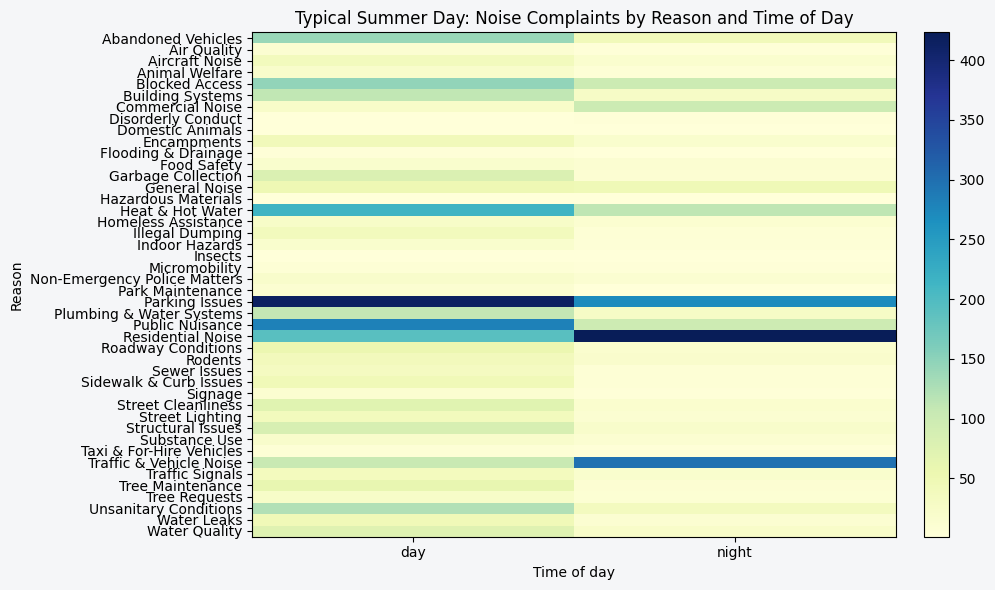

In [8]:
plt.figure(figsize=(10, 6), facecolor="#F5F6F8")
ax = plt.gca()
ax.set_facecolor("#FFFFFF")

im = ax.imshow(
    heatmap_df.values,
    aspect="auto",
    cmap="YlGnBu"
)



ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=0)
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

ax.set_title("Typical Summer Day: Noise Complaints by Reason and Time of Day", fontsize=12)
ax.set_xlabel("Time of day")
ax.set_ylabel("Reason")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

#### 3) Day-of-week complaint 

In [9]:
def daily_by_reason_time_dow(df: pd.DataFrame) -> pd.DataFrame:
    """Daily citywide totals by descriptor_group × time_of_day × dow."""
    return (
        df.groupby([df["complaint_date"].dt.date, "category", "dow", "time_of_day"])["complaint_count"]
          .sum()
          .reset_index(name="daily_complaints")
    )

def summarize_dow_profile(daily: pd.DataFrame) -> pd.DataFrame:
    """Mean and 10–90% range of daily complaints by descriptor_group × dow × time_of_day."""
    summary = (
        daily.groupby(["category", "dow", "time_of_day"])["daily_complaints"]
             .agg(
                 mean="mean",
                 p10=lambda x: x.quantile(0.10),
                 p90=lambda x: x.quantile(0.90),
             )
             .reset_index()
    )
    summary["dow"] = pd.Categorical(summary["dow"], categories=DOW_ORDER, ordered=True)
    return summary.sort_values("dow")

In [10]:
DOW_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

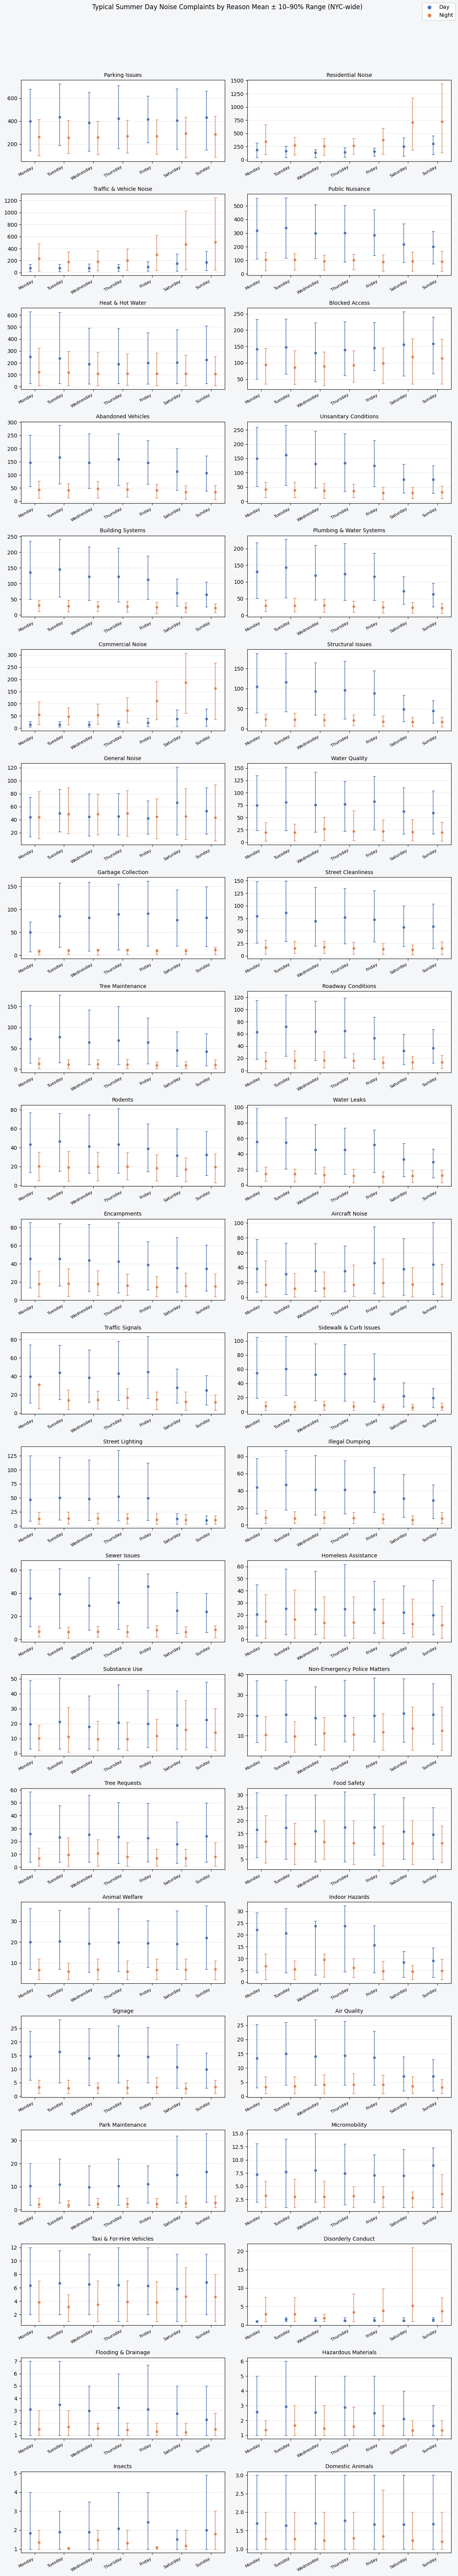

In [11]:
daily = daily_by_reason_time_dow(df_nta_2021__2024)
summary = summarize_dow_profile(daily)

categories = (
  summary.groupby("category")["mean"]
  .mean()
  .sort_values(ascending=False)
  .index
  .tolist()
)

n = len(categories)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
  nrows=nrows,
  ncols=ncols,
  figsize=(ncols * 6, nrows * 3),
  sharey=False,
  facecolor="#F5F6F8",
)
axes = np.atleast_1d(axes).flatten()

colors = {"day": "#4C72B0", "night": "#DD8452"}
offset = {"day": -0.15, "night": 0.15}
x = np.arange(len(DOW_ORDER))

for ax, group in zip(axes, categories):
  ax.set_facecolor("#FFFFFF")
  g = summary[summary["category"] == group]

  for tod in ["day", "night"]:
      d = (
          g[g["time_of_day"] == tod]
          .set_index("dow")
          .reindex(DOW_ORDER)
          .reset_index()
      )

      if d["mean"].notna().sum() == 0:
          continue

      mean = d["mean"].to_numpy(dtype=float)
      p10 = d["p10"].to_numpy(dtype=float)
      p90 = d["p90"].to_numpy(dtype=float)

      lower = np.clip(mean - p10, 0, None)
      upper = np.clip(p90 - mean, 0, None)
      yerr = np.vstack([lower, upper])

      ax.errorbar(
          x + offset[tod],
          mean,
          yerr=yerr,
          fmt="o",
          markersize=4,
          capsize=3,
          elinewidth=1.1,
          color=colors[tod],
          label=tod.capitalize() if ax is axes[0] else None,
      )

  ax.set_title(group, fontsize=10)
  ax.set_xticks(x)
  ax.set_xticklabels(DOW_ORDER, rotation=30, ha="right", fontsize=8)
  ax.grid(axis="y", alpha=0.3)

for ax in axes[len(categories):]:
  ax.axis("off")

fig.suptitle(
  "Typical Summer Day Noise Complaints by Reason Mean ± 10–90% Range (NYC-wide)",
  fontsize=12,
  y=1.02,
)

fig.legend(
  handles=[
      plt.Line2D([0], [0], marker="o", color=colors["day"], label="Day", linestyle=""),
      plt.Line2D([0], [0], marker="o", color=colors["night"], label="Night", linestyle=""),
  ],
  loc="upper right",
)

plt.tight_layout()
plt.show()

#### 4) Neighborhood composition: Top/Bottom neighborhoods (day vs night)

In [14]:
from IPython.display import display

nta_category_daily = (
    df_nta_2021__2024
    .groupby([
        df_nta_2021__2024["complaint_date"].dt.date,
        "nta_name",
        "borough",
        "category",
    ], as_index=False)["complaint_count"]
    .sum()
    .rename(columns={"complaint_date": "date", "complaint_count": "daily_complaints"})
)

nta_category_summary = (
    nta_category_daily
    .groupby(["nta_name", "borough", "category"], as_index=False)["daily_complaints"]
    .mean()
)

nta_category_summary["category_rank"] = (
    nta_category_summary
    .groupby("nta_name")["daily_complaints"]
    .rank(method="first", ascending=False)
    .astype(int)
)

top10_by_nta = (
    nta_category_summary
    .loc[nta_category_summary["category_rank"] <= 10]
    .sort_values(["nta_name", "category_rank"])
    .reset_index(drop=True)
)

nta_daily_totals = (
    df_nta_2021__2024
    .groupby([
        df_nta_2021__2024["complaint_date"].dt.date,
        "nta_name",
        "borough",
    ], as_index=False)["complaint_count"]
    .sum()
    .rename(columns={"complaint_date": "date", "complaint_count": "daily_complaints"})
)

nta_totals = (
    nta_daily_totals
    .groupby(["nta_name", "borough"], as_index=False)["daily_complaints"]
    .mean()
    .sort_values("daily_complaints", ascending=False)
    .reset_index(drop=True)
)
nta_totals["nta_rank"] = np.arange(1, len(nta_totals) + 1)

top_nta_names = nta_totals.head(10)["nta_name"]
top10_focus = top10_by_nta[top10_by_nta["nta_name"].isin(top_nta_names)].copy()

display(
    nta_totals.head(10)[["nta_rank", "nta_name", "borough", "daily_complaints"]]
    .rename(columns={"daily_complaints": "avg_daily_complaints"})
)

display(
    top10_focus[["nta_name", "borough", "category_rank", "category", "daily_complaints"]]
    .rename(columns={"daily_complaints": "avg_daily_complaints"})
    .sort_values(["nta_name", "category_rank"])
    .reset_index(drop=True)
)


,nta_rank,nta_name,borough,avg_daily_complaints
0,1,Wakefield-Woodlawn,Bronx,122.941176
1,2,Harlem (North),Manhattan,61.742424
2,3,Washington Heights (South),Manhattan,57.864711
3,4,Washington Heights (North),Manhattan,56.539262
4,5,South Ozone Park,Queens,52.480114
5,6,Crown Heights (North),Brooklyn,52.302744
6,7,Hamilton Heights-Sugar Hill,Manhattan,48.982008
7,8,Concourse-Concourse Village,Bronx,47.506629
8,9,Bedford-Stuyvesant (West),Brooklyn,47.010417
9,10,East Village,Manhattan,46.757576


,nta_name,borough,category_rank,category,avg_daily_complaints
0,Bedford-Stuyvesant (West),Brooklyn,1,Residential Noise,6.925813
1,Bedford-Stuyvesant (West),Brooklyn,2,Traffic & Vehicle Noise,5.881928
2,Bedford-Stuyvesant (West),Brooklyn,3,Parking Issues,4.835588
3,Bedford-Stuyvesant (West),Brooklyn,4,Public Nuisance,4.644809
4,Bedford-Stuyvesant (West),Brooklyn,5,Heat & Hot Water,3.824113
...,...,...,...,...,...
95,Washington Heights (South),Manhattan,6,Water Quality,3.710784
96,Washington Heights (South),Manhattan,7,Commercial Noise,3.594502
97,Washington Heights (South),Manhattan,8,Tree Requests,3.577320
98,Washington Heights (South),Manhattan,9,Building Systems,3.568773


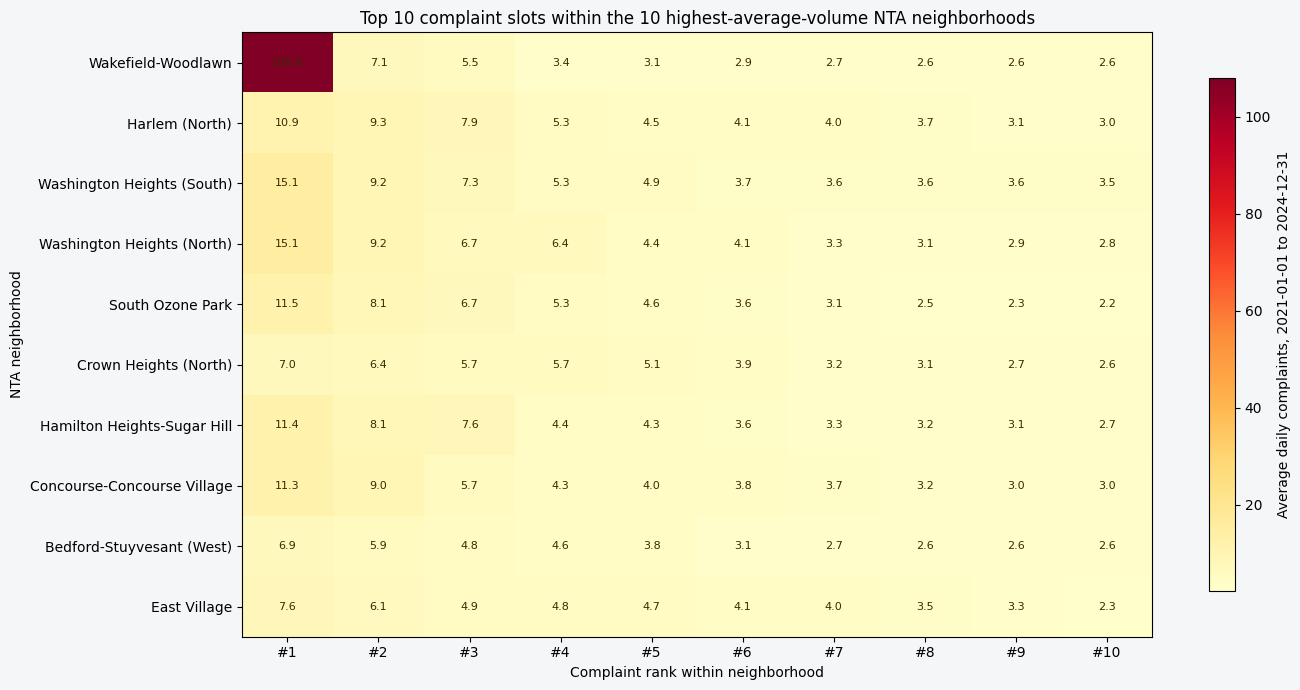

,nta_name,borough,top_complaint,top_complaint_avg_daily
0,Wakefield-Woodlawn,Bronx,Residential Noise,108.016520
1,Washington Heights (North),Manhattan,Traffic & Vehicle Noise,15.109034
2,Washington Heights (South),Manhattan,Traffic & Vehicle Noise,15.094340
3,South Ozone Park,Queens,Residential Noise,11.512088
4,Hamilton Heights-Sugar Hill,Manhattan,Traffic & Vehicle Noise,11.398268
5,Concourse-Concourse Village,Bronx,Traffic & Vehicle Noise,11.267073
6,Harlem (North),Manhattan,Residential Noise,10.902791
7,East Village,Manhattan,Residential Noise,7.626775
8,Crown Heights (North),Brooklyn,Residential Noise,6.990982
9,Bedford-Stuyvesant (West),Brooklyn,Residential Noise,6.925813


In [16]:
heatmap_rank = (
    top10_focus
    .pivot(index="nta_name", columns="category_rank", values="daily_complaints")
    .reindex(index=nta_totals.head(10)["nta_name"].tolist(), columns=range(1, 11))
    .fillna(0)
)

category_labels = {}
for _, row in top10_focus.iterrows():
    category_labels.setdefault(row["category_rank"], row["category"])

fig, ax = plt.subplots(figsize=(14, 7), facecolor="#F5F6F8")
ax.set_facecolor("#FFFFFF")
im = ax.imshow(heatmap_rank.to_numpy(), aspect="auto", cmap="YlOrRd")

ax.set_xticks(np.arange(10))
ax.set_xticklabels([f"#{i}" for i in range(1, 11)])
ax.set_yticks(np.arange(len(heatmap_rank.index)))
ax.set_yticklabels(heatmap_rank.index)
ax.set_xlabel("Complaint rank within neighborhood")
ax.set_ylabel("NTA neighborhood")
ax.set_title("Top 10 complaint slots within the 10 highest-average-volume NTA neighborhoods")

for i in range(heatmap_rank.shape[0]):
    for j in range(heatmap_rank.shape[1]):
        value = heatmap_rank.iloc[i, j]
        if value > 0:
            ax.text(j, i, f"{value:.1f}", ha="center", va="center", fontsize=8, color="#3A2A00")

cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("Average daily complaints, 2021-01-01 to 2024-12-31")

plt.tight_layout()
plt.show()

top_complaint_summary = (
    top10_focus
    .loc[top10_focus["category_rank"] == 1, ["nta_name", "borough", "category", "daily_complaints"]]
    .rename(columns={"category": "top_complaint", "daily_complaints": "top_complaint_avg_daily"})
    .sort_values("top_complaint_avg_daily", ascending=False)
    .reset_index(drop=True)
)

top_complaint_summary
